In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from utils import process_rw_file
import numpy as np
from utils import (load_graph_from_txt, compute_energy, compute_neighbor_loss_over_records)
import torch

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)

In [46]:
def compute_aligned_loss_energy(
    directory: str,
    vocab_path: Path = Path("../data/words_dict.txt"),
    graph_kind: str = "tree",
    win: int = 20,
    pca_k: int = 2,
    pc1:int = 0,
    pc2:int = 1,
    k_last: int = 5,
    step_topk: int = 10,
    layer: int = 32,
):
    """
    Restituisce TUTTO già pronto per un plot unico su asse x comune:
      - x_tokens  (T,)
      - loss_on_x (T,)  loss interpolata sugli stessi x di energy
      - energy_y  (T,)

    Nota: loss_on_x è ottenuta riscalando la x della loss sulla scala token e interpolando su x_tokens.
    """

    emb_dir     = Path(f"../embeddings/{directory}")
    struct_path = Path(f"../data/one_random_walk/{directory}/structure.txt")

    # embeddings file (serve a compute_energy)
    embs_file = emb_dir / f"reprs_{directory}_line000000_layer{layer}.pt"
    _ids_np, _emb_np = load_embeddings_pt(embs_file)

    # graph
    G = load_graph_from_txt(struct_path, kind=graph_kind)

    # topk records -> loss
    probs_file = emb_dir / f"topk_step{step_topk}_{directory}.pt"
    data = torch.load(probs_file, map_location="cpu")
    records = data.get("records", [])

    _, df_loss = compute_neighbor_loss_over_records(
        records, G,
        topk_field="top_decoded",
        probs_field="top_probs",
        lowercase=True,
    )

    df = df_loss.copy()
    df["length_tokens"] = df["token_position_1based"].astype(int)

    mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
    dfv = df.loc[mask].sort_values("length_tokens")

    if len(dfv) == 0:
        raise ValueError("Nessun record valido per la loss dopo il filtering (dfv è vuoto).")

    loss_x_words = dfv["length_tokens"].to_numpy(dtype=float)
    loss_y = dfv["loss_topk"].to_numpy(dtype=float)

    if loss_x_words.max() == 0:
        raise ValueError("loss_x_words.max()==0: impossibile riscalare l'asse x della loss.")

    # energy
    min_nodes = pca_k + 1
    energy_out = compute_energy(
        VOCAB_PATH=vocab_path,
        GRID_PATH=struct_path,
        EMB_DIR=emb_dir,
        WIN=win,
        PCA_K=pca_k,
        pc1=pc1,
        pc2=pc2,
        K=k_last,
        MIN_NODES=min_nodes,
        pt_filename=embs_file.name,
        graph_kind=graph_kind,
    )

    x_tokens = np.asarray(energy_out[0], dtype=float)
    energy_y = np.asarray(energy_out[1], dtype=float)

    if x_tokens.size == 0:
        raise ValueError("energy_x_tokens è vuoto: compute_energy ha restituito un asse x vuoto.")

    # --- ALLINEAMENTO (una volta sola, qui dentro)
    # riscala asse x della loss sulla scala token
    loss_x_tokens = loss_x_words * (x_tokens.max() / loss_x_words.max())

    # interpola loss sugli stessi x della energy
    loss_on_x = np.interp(x_tokens, loss_x_tokens, loss_y)

    return x_tokens, loss_on_x, energy_y

# Words

## Tree

[WARN] Record non valutabile (pos 2, line 0): observed_token_not_in_graph (observed_raw='under')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'flu' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'culprit' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'flu' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'blackout' has only 2 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'nonatomic' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'mafia' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token 'blackout' has only 2 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token 'nonatomic' has only 2 occurrences in [0:80] (requested 5)
  [ctx=2000, win_le

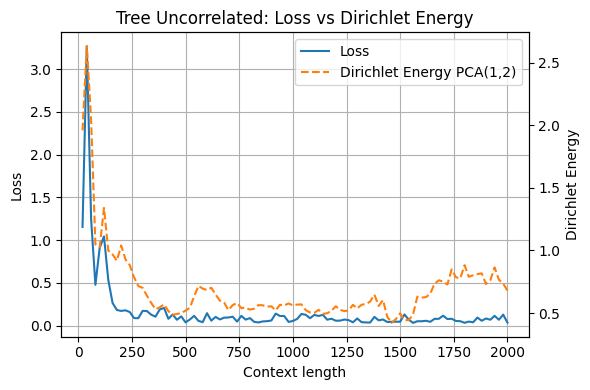

In [ ]:
directory = "tree_uncorrelated" 
VOCAB_PATH  = Path("../data/words_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

k_last = 5

x_tokens, loss_tree, energy_tree = compute_aligned_loss_energy(
    directory=directory,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_tree, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_tree, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
# fig.savefig(f"../plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[np.argmin(energy_tree)])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))


embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                    k=k_last, t_start=0, t_end=win_opt)
pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:,0:2]

hp_tree.plot_reduced_emb(axes[0], pca_result, filtered_ids, title=f"Context Win: 0:{win_opt}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)


# -------------------------------- DENDROGRAM -------------------------------- #

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 2 # quale livello dell'albero dendrogrammo per i centroidi
layer3 = 1

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2 or depth == layer3]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

mask_layer_l = np.isin(ids_np, ids_layer_l)
emb_dendro = emb_np[mask_layer_l]
ids_dendro = ids_np[mask_layer_l]


centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

hp_tree.plot_dendrogram_on_points(axes[1], centroids_id, centroids_emb, title=f"Context Win: 0:{win_opt}", 
                                  method="ward", max_leaves=50, leaf_font_size=8)

fig.suptitle(f"Dendrogram of embedding centroids - {directory.replace('_', ' ').title()}",
             fontsize=15, y=1.01)


fig.tight_layout()
fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

## Grid

In [ ]:
directory = "grid_square_uncorrelated" 
VOCAB_PATH  = Path("../data/words_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
k_last = 5

x_tokens, loss_grid, energy_grid = compute_aligned_loss_energy(
    directory=directory,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_grid, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_grid, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
# fig.savefig(f"../plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[np.argmin(energy_grid[2:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal')
fig.tight_layout()

fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## Circle

In [ ]:
directory = "circle_uncorrelated_alt" 
VOCAB_PATH  = Path("../data/words_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

x_tokens, loss_circle, energy_circle = compute_aligned_loss_energy(
    directory=directory,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_circle, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_circle, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
# fig.savefig(f"../plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[np.argmin(energy_circle[2:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal')
fig.tight_layout()

fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## all losses and enerigies

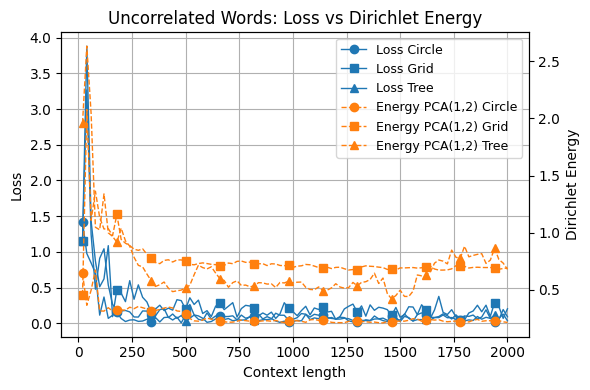

In [ ]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(True)

loss_color = "tab:blue"
energy_color = "tab:orange"

# stili per shape
loss_styles = {
    "Circle": dict(linestyle="-",  marker="o", markevery=8),
    "Grid":   dict(linestyle="-",  marker="s", markevery=8),
    "Tree":   dict(linestyle="-",  marker="^", markevery=8),
}

energy_styles = {
    "Circle": dict(linestyle="--", marker="o", markevery=8),              # dashed
    "Grid":   dict(linestyle="--", marker="s", markevery=8),              # dash-dot
    "Tree":   dict(linestyle="--",  marker="^", markevery=8),              # dotted
}

# LOSS (tutte blu)
line1 = ax1.plot(x_tokens, loss_circle, label="Loss Circle",
                 color=loss_color, linewidth=1, **loss_styles["Circle"])
line2 = ax1.plot(x_tokens, loss_grid, label="Loss Grid",
                 color=loss_color, linewidth=1, **loss_styles["Grid"])
line3 = ax1.plot(x_tokens, loss_tree, label="Loss Tree",
                 color=loss_color, linewidth=1, **loss_styles["Tree"])

# ENERGY (tutte arancioni) su asse destro
ax2 = ax1.twinx()
ax2.set_ylabel("Dirichlet Energy")

line4 = ax2.plot(x_tokens, energy_circle, label="Energy PCA(1,2) Circle",
                 color=energy_color, linewidth=1, **energy_styles["Circle"])
line5 = ax2.plot(x_tokens, energy_grid, label="Energy PCA(1,2) Grid",
                 color=energy_color, linewidth=1, **energy_styles["Grid"])
line6 = ax2.plot(x_tokens, energy_tree, label="Energy PCA(1,2) Tree",
                 color=energy_color, linewidth=1, **energy_styles["Tree"])

# legenda unica
lines = line1 + line2 + line3 + line4 + line5 + line6
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best", fontsize=9)

plt.title(f"Uncorrelated Words: Loss vs Dirichlet Energy")
fig.tight_layout()
plt.show()

# Numbers

  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '12' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '15' has only 4 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '12' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '12' has only 3 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '8' has only 1 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '12' has only 4 occurrences in [0:100] (requested 5)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '8' has only 1 occurrences in [0:100] (requested 5)
  [ctx=2000, win_len=120, local=[0:120)] Warning: token '4' has only 1 occurrences in [0:120] (requested 5)
  [ctx=2000, win_len=120, local=[0:120)]

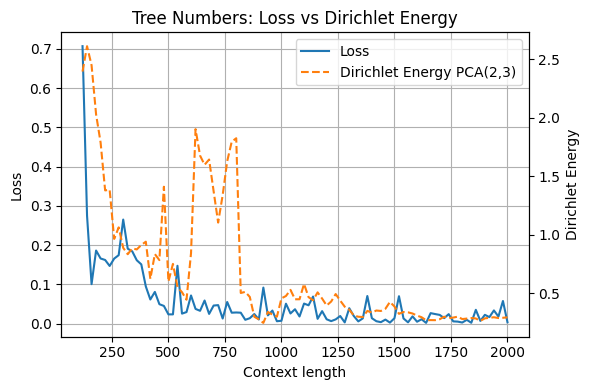

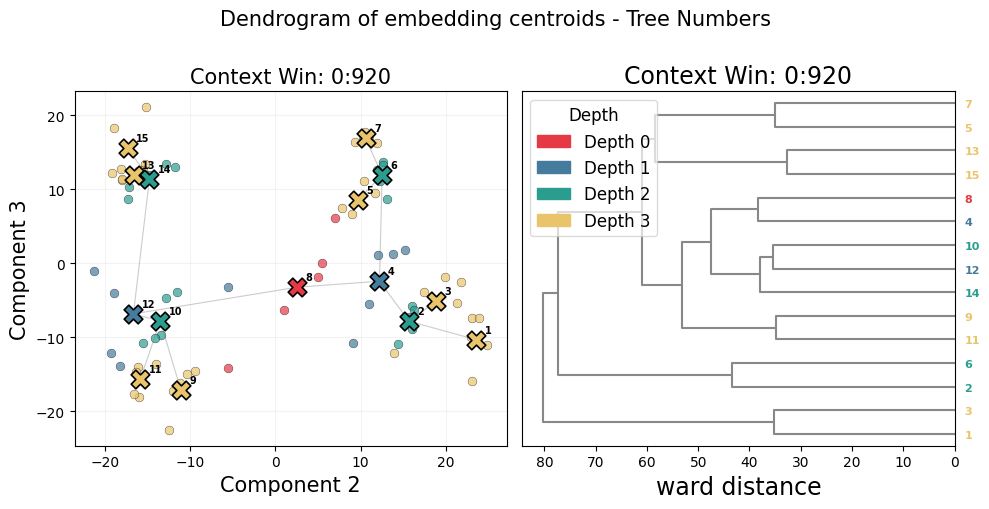

In [49]:
directory = "tree_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

k_last = 5
pc1, pc2 = 1, 2

x_tokens, loss_tree, energy_tree = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=5,
    pc1=pc1,
    pc2=pc2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_tree, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_tree, "--", label=f"Dirichlet Energy PCA({pc1+1},{pc2+1})", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
# fig.savefig(f"../plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[np.argmin(energy_tree)])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))


embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                    k=k_last, t_start=0, t_end=win_opt)


pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:,[pc1, pc2]]

hp_tree.plot_reduced_emb(axes[0], pca_result, filtered_ids, title=f"Context Win: 0:{win_opt}", only_centroid=False, second_components=True)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)


# -------------------------------- DENDROGRAM -------------------------------- #

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 2 # quale livello dell'albero dendrogrammo per i centroidi
layer3 = 1

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2 or depth == layer3]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

mask_layer_l = np.isin(ids_np, ids_layer_l)
emb_dendro = emb_np[mask_layer_l]
ids_dendro = ids_np[mask_layer_l]


centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

hp_tree.plot_dendrogram_on_points(axes[1], centroids_id, centroids_emb, title=f"Context Win: 0:{win_opt}", 
                                  method="ward", max_leaves=50, leaf_font_size=8)

fig.suptitle(f"Dendrogram of embedding centroids - {directory.replace('_', ' ').title()}",
             fontsize=15, y=1.01)


fig.tight_layout()
fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()